In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# ============================================================
# Part 1: 数据预处理
# ============================================================
print("=" * 60)
print("Part 1: 数据预处理")
print("=" * 60)

df = pd.read_csv('house_shenzhen_s.csv', encoding='gbk')
print(f"原始数据: {df.shape}")

df.drop(columns=['unitprice', 'position'], inplace=True)

rooms_split = df['rooms'].str.extract(r'(\d+)室(\d+)厅')
df['room_num'] = rooms_split[0].astype(int)
df['hall_num'] = rooms_split[1].astype(int)
df.drop(columns=['rooms'], inplace=True)

def map_height(x):
    if pd.isna(x): return np.nan
    s = str(x)
    if '高' in s: return 3
    if '中' in s: return 2
    if '低' in s: return 1
    return np.nan

df['height'] = df['height'].apply(map_height)
df['decoration'] = df['decoration'].map({'精装': 2, '简装': 1}).fillna(0).astype(int)
df['elevator'] = df['elevator'].map({'有电梯': 1, '无电梯': 0}).fillna(0).astype(int)

df['building_age'] = 2026 - df['year']
df.drop(columns=['year'], inplace=True)
valid_age = (df['building_age'] >= 0) & (df['building_age'] <= 200)
df.loc[~valid_age, 'building_age'] = df.loc[valid_age, 'building_age'].median()

df['follow'] = np.log1p(df['follow'])

for d in ['东', '南', '西', '北']:
    df[f'ori_{d}'] = df['orientation'].fillna('').apply(lambda x: 1 if d in x else 0)
df.drop(columns=['orientation'], inplace=True)

area_counts = df['area'].value_counts()
rare_areas = area_counts[area_counts < 10].index.tolist()
df['area'] = df['area'].apply(lambda x: '其他' if x in rare_areas else x)
print(f"area 类别数: {df['area'].nunique()} (合并低频后，原始83类)")

df = pd.get_dummies(df, columns=['area'], prefix='area', dtype=int)
df = pd.get_dummies(df, columns=['buildtype'], prefix='buildtype', dtype=int)
df = pd.get_dummies(df, columns=['city'], prefix='city', dtype=int)
df.fillna(0, inplace=True)

print(f"预处理后: {df.shape}")

# ============================================================
# Part 2: 数据清洗
# ============================================================
print("\n" + "=" * 60)
print("Part 2: 数据清洗")
print("=" * 60)

n_before = len(df)
df = df[df['size'] > 0]
df = df[df['height'] > 0]
df = df[df['building_age'] <= 80]
print(f"清洗后: {df.shape} (删除 {n_before - len(df)} 行)")

# ============================================================
# Part 3: 第一轮 — 全特征训练，识别低贡献特征
# ============================================================
print("\n" + "=" * 60)
print("Part 3: 第一轮 — 全特征训练")
print("=" * 60)

target_col = 'totalprice'
feature_cols_all = [c for c in df.columns if c != target_col]

X_all = df[feature_cols_all].copy()
y_all = df[target_col].copy()

scaler = StandardScaler()
X_scaled_all = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_cols_all)
y_sqrt_all = np.sqrt(y_all)

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_scaled_all, y_sqrt_all, test_size=0.2, random_state=2024
)
_, _, y_tr1_raw, y_te1_raw = train_test_split(
    X_scaled_all, y_all, test_size=0.2, random_state=2024
)

param_dist = {
    'n_estimators': [300, 400, 500, 600, 700, 800, 1000],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.04, 0.05, 0.06, 0.07, 0.08],
    'subsample': [0.7, 0.75, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.75, 0.8, 0.85, 0.9],
    'reg_alpha': [0, 0.1, 0.3, 0.5, 0.8, 1.0],
    'reg_lambda': [0.1, 0.3, 0.5, 0.8, 1.0, 1.5],
    'min_child_weight': [3, 5, 7, 9],
}

xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror')
search1 = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5,
                             scoring='neg_mean_absolute_percentage_error',
                             random_state=42, n_jobs=-1, verbose=0)
search1.fit(X_tr1, y_tr1)

m1 = XGBRegressor(**search1.best_params_, random_state=42, n_jobs=-1, verbosity=0)
m1.fit(X_tr1, y_tr1)
pred1 = m1.predict(X_te1) ** 2
r2_1 = r2_score(y_te1_raw, pred1)
mape_1 = mean_absolute_percentage_error(y_te1_raw, pred1) * 100

m1_full = XGBRegressor(**search1.best_params_, random_state=42, n_jobs=-1, verbosity=0)
m1_full.fit(X_scaled_all, y_sqrt_all)
raw_imp1 = dict(zip(feature_cols_all, m1_full.feature_importances_))

# 合并同类特征贡献率
groups = {
    'area':        [c for c in feature_cols_all if c.startswith('area_')],
    'city':        [c for c in feature_cols_all if c.startswith('city_')],
    'orientation': [c for c in feature_cols_all if c.startswith('ori_')],
    'buildtype':   [c for c in feature_cols_all if c.startswith('buildtype_')],
    'rooms':       ['room_num', 'hall_num'],
}
grouped = set()
for cols in groups.values():
    grouped.update(cols)

merged1 = {}
for name, cols in groups.items():
    merged1[name] = sum(raw_imp1[c] for c in cols)
for col in feature_cols_all:
    if col not in grouped:
        merged1[col] = raw_imp1[col]
merged1_sorted = sorted(merged1.items(), key=lambda x: x[1], reverse=True)

print(f"\n  全特征 R2={r2_1:.5f}  MAPE={mape_1:.2f}%")
print(f"\n  [全特征贡献率]")
print(f"    {'排名':<5} {'特征':<16} {'贡献率':<10} {'累计':<10}")
print(f"    {'-'*41}")
cum = 0
for rank, (feat, imp) in enumerate(merged1_sorted, 1):
    cum += imp
    print(f"    {rank:<5} {feat:<16} {imp:<10.4f} {cum:<10.4f}  {'|'*int(imp*100)}")

# 找出非合并类中贡献率最低的 3 个
non_grouped = [feat for feat, _ in merged1_sorted
               if feat not in ['area', 'city', 'orientation', 'buildtype', 'rooms']]
non_grouped_sorted = sorted(non_grouped, key=lambda x: merged1[x])
drop_feats = non_grouped_sorted[:3]
print(f"\n  >>> 贡献率最低的 3 个特征: {drop_feats}")

# ============================================================
# Part 4: 第二轮 — 剔除低贡献特征重跑
# ============================================================
print("\n" + "=" * 60)
print("Part 4: 第二轮 — 剔除低贡献特征重跑")
print("=" * 60)

df2 = df.drop(columns=drop_feats)
print(f"剔除后数据: {df2.shape}")

feature_cols = [c for c in df2.columns if c != target_col]
X = df2[feature_cols].copy()
y = df2[target_col].copy()

scaler2 = StandardScaler()
X_scaled = pd.DataFrame(scaler2.fit_transform(X), columns=feature_cols)
y_sqrt = np.sqrt(y)

X_train, X_test, y_train_sqrt, y_test_sqrt = train_test_split(
    X_scaled, y_sqrt, test_size=0.2, random_state=2024
)
_, _, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, random_state=2024
)
print(f"训练集: {len(X_train)}, 测试集: {len(X_test)}")

xgb2 = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror')
search2 = RandomizedSearchCV(xgb2, param_dist, n_iter=50, cv=5,
                             scoring='neg_mean_absolute_percentage_error',
                             random_state=42, n_jobs=-1, verbose=0)
search2.fit(X_train, y_train_sqrt)

best_params = search2.best_params_
print(f"最佳参数: {best_params}")

model = XGBRegressor(**best_params, random_state=42, n_jobs=-1, verbosity=0)
model.fit(X_train, y_train_sqrt)

test_pred = model.predict(X_test) ** 2
test_r2 = r2_score(y_test_raw, test_pred)
test_mape = mean_absolute_percentage_error(y_test_raw, test_pred) * 100

print(f"\n  最终测试集 R2:   {test_r2:.5f}")
print(f"  最终测试集 MAPE: {test_mape:.2f}%")

model_full = XGBRegressor(**best_params, random_state=42, n_jobs=-1, verbosity=0)
model_full.fit(X_scaled, y_sqrt)

# ============================================================
# Part 5: 最终特征重要性
# ============================================================
raw_importance = dict(zip(feature_cols, model_full.feature_importances_))

merged_importance = {}
for name, cols in groups.items():
    cols_in = [c for c in cols if c in feature_cols]
    if cols_in:
        merged_importance[name] = sum(raw_importance[c] for c in cols_in)
for col in feature_cols:
    if col not in grouped:
        merged_importance[col] = raw_importance[col]

merged_sorted = sorted(merged_importance.items(), key=lambda x: x[1], reverse=True)

print(f"\n  [最终特征贡献率]")
print(f"    {'排名':<5} {'特征':<16} {'贡献率':<10} {'累计':<10}")
print(f"    {'-'*41}")
cumsum = 0
for rank, (feat, imp) in enumerate(merged_sorted, 1):
    cumsum += imp
    print(f"    {rank:<5} {feat:<16} {imp:<10.4f} {cumsum:<10.4f}  {'|'*int(imp*100)}")

# ============================================================
# Part 6: 最终结果摘要
# ============================================================
print("\n" + "=" * 60)
print("  最终结果摘要")
print("=" * 60)
print(f"\n  R2 变化: {r2_1:.5f} -> {test_r2:.5f} (+{test_r2 - r2_1:.5f})")
print(f"  MAPE:    {mape_1:.2f}% -> {test_mape:.2f}%")
print(f"  剔除特征: {drop_feats}")
print(f"  特征数:   {len(feature_cols_all)} -> {len(feature_cols)}")
print(f"\n  [最终模型超参数]")
for k, v in best_params.items():
    print(f"    {k:<20} = {v}")
print(f"    {'target_transform':<20} = sqrt")

# ============================================================
# Part 7: 保存
# ============================================================
df2.to_csv('house_shenzhen_processed_final.csv', index=False, encoding='utf-8-sig')
print("\n已保存: house_shenzhen_processed_final.csv")

full_pred = model_full.predict(X_scaled) ** 2
df_out = df2.copy()
df_out['predicted_price'] = full_pred
df_out['abs_error'] = np.abs(y - full_pred)
df_out['pct_error'] = np.abs(y - full_pred) / y * 100
df_out.to_csv('house_shenzhen_predicted_final.csv', index=False, encoding='utf-8-sig')
print("已保存: house_shenzhen_predicted_final.csv")
print("\nDone.")

Part 1: 数据预处理
原始数据: (6064, 14)
area 类别数: 77 (合并低频后，原始83类)
预处理后: (6064, 100)

Part 2: 数据清洗
清洗后: (6040, 100) (删除 24 行)

Part 3: 第一轮 — 全特征训练



  全特征 R2=0.93429  MAPE=10.36%

  [全特征贡献率]
    排名    特征               贡献率        累计        
    -----------------------------------------
    1     area             0.5431     0.5431      ||||||||||||||||||||||||||||||||||||||||||||||||||||||
    2     city             0.2878     0.8309      ||||||||||||||||||||||||||||
    3     rooms            0.0709     0.9019      |||||||
    4     size             0.0645     0.9664      ||||||
    5     orientation      0.0091     0.9755      
    6     buildtype        0.0086     0.9841      
    7     building_age     0.0058     0.9898      
    8     elevator         0.0041     0.9939      
    9     follow           0.0027     0.9967      
    10    decoration       0.0021     0.9987      
    11    height           0.0013     1.0000      

  >>> 贡献率最低的 3 个特征: ['height', 'decoration', 'follow']

Part 4: 第二轮 — 剔除低贡献特征重跑
剔除后数据: (6040, 97)
训练集: 4832, 测试集: 1208


最佳参数: {'subsample': 0.8, 'reg_lambda': 0.3, 'reg_alpha': 0.3, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.04, 'colsample_bytree': 0.8}



  最终测试集 R2:   0.94395
  最终测试集 MAPE: 10.36%



  [最终特征贡献率]
    排名    特征               贡献率        累计        
    -----------------------------------------
    1     area             0.5606     0.5606      ||||||||||||||||||||||||||||||||||||||||||||||||||||||||
    2     city             0.3058     0.8664      ||||||||||||||||||||||||||||||
    3     size             0.0724     0.9388      |||||||
    4     rooms            0.0326     0.9714      |||
    5     buildtype        0.0102     0.9816      |
    6     orientation      0.0081     0.9898      
    7     building_age     0.0053     0.9951      
    8     elevator         0.0049     1.0000      

  最终结果摘要

  R2 变化: 0.93429 -> 0.94395 (+0.00966)
  MAPE:    10.36% -> 10.36%
  剔除特征: ['height', 'decoration', 'follow']
  特征数:   99 -> 96

  [最终模型超参数]
    subsample            = 0.8
    reg_lambda           = 0.3
    reg_alpha            = 0.3
    n_estimators         = 800
    min_child_weight     = 3
    max_depth            = 7
    learning_rate        = 0.04
    colsample_bytree 

已保存: house_shenzhen_predicted_final.csv

Done.


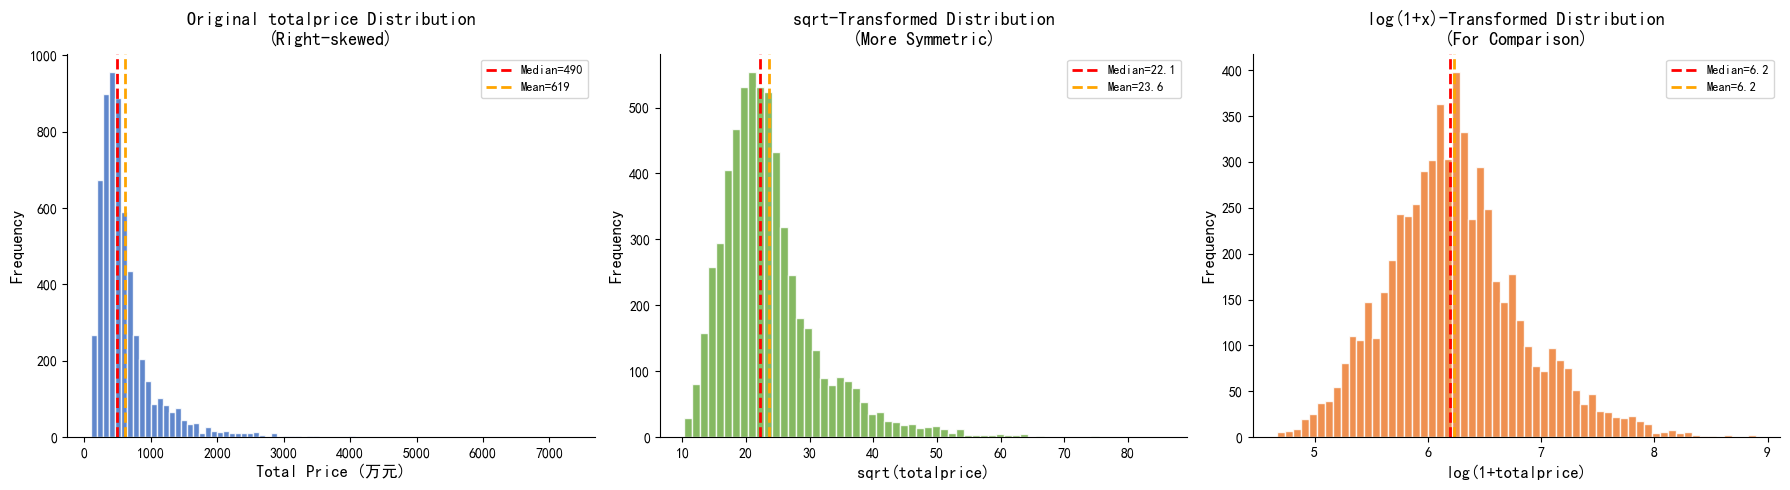

已保存: fig1_totalprice_distribution.png


In [2]:
# ============================================================
# 补充图1: totalprice 分布直方图 (支撑 sqrt 变换的合理性)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取原始数据用于展示目标变量分布
df_raw = pd.read_csv('house_shenzhen_s.csv', encoding='gbk')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: 原始 totalprice 分布
ax1 = axes[0]
ax1.hist(df_raw['totalprice'], bins=80, color='#4472C4', edgecolor='white', alpha=0.85)
ax1.axvline(df_raw['totalprice'].median(), color='red', linestyle='--', linewidth=2, label=f"Median={df_raw['totalprice'].median():.0f}")
ax1.axvline(df_raw['totalprice'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean={df_raw['totalprice'].mean():.0f}")
ax1.set_xlabel('Total Price (万元)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Original totalprice Distribution\n(Right-skewed)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2: sqrt 变换后的分布
ax2 = axes[1]
y_sqrt_viz = np.sqrt(df_raw['totalprice'])
ax2.hist(y_sqrt_viz, bins=60, color='#70AD47', edgecolor='white', alpha=0.85)
ax2.axvline(y_sqrt_viz.median(), color='red', linestyle='--', linewidth=2, label=f"Median={y_sqrt_viz.median():.1f}")
ax2.axvline(y_sqrt_viz.mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean={y_sqrt_viz.mean():.1f}")
ax2.set_xlabel('sqrt(totalprice)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('sqrt-Transformed Distribution\n(More Symmetric)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3: log 变换后的分布 (对比)
ax3 = axes[2]
y_log_viz = np.log1p(df_raw['totalprice'])
ax3.hist(y_log_viz, bins=60, color='#ED7D31', edgecolor='white', alpha=0.85)
ax3.axvline(y_log_viz.median(), color='red', linestyle='--', linewidth=2, label=f"Median={y_log_viz.median():.1f}")
ax3.axvline(y_log_viz.mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean={y_log_viz.mean():.1f}")
ax3.set_xlabel('log(1+totalprice)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('log(1+x)-Transformed Distribution\n(For Comparison)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig1_totalprice_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存: fig1_totalprice_distribution.png')


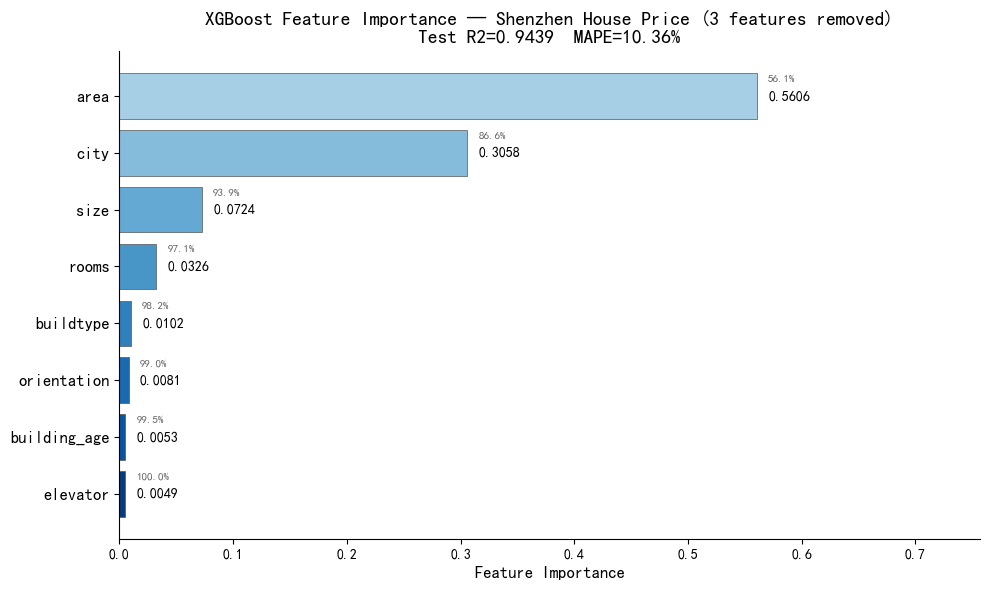

已保存: feature_importance_final.png


In [3]:
# ============================================================
# Part 6.5: 特征贡献率可视化
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

features = [x[0] for x in merged_sorted]
importances = [x[1] for x in merged_sorted]
cumsum_vals = np.cumsum(importances)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(features)))
ax.barh(range(len(features)), importances, color=colors, edgecolor='#555', linewidth=0.5)

for i, (feat, imp, cum) in enumerate(zip(features, importances, cumsum_vals)):
    ax.text(imp + 0.01, i, f'{imp:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.text(imp + 0.01, i - 0.3, f'{cum:.1%}', va='center', fontsize=8, color='#666')

ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title(f'XGBoost Feature Importance — Shenzhen House Price (3 features removed)\nTest R2={test_r2:.4f}  MAPE={test_mape:.2f}%', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(importances) * 1.35)

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\feature_importance_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("已保存: feature_importance_final.png")

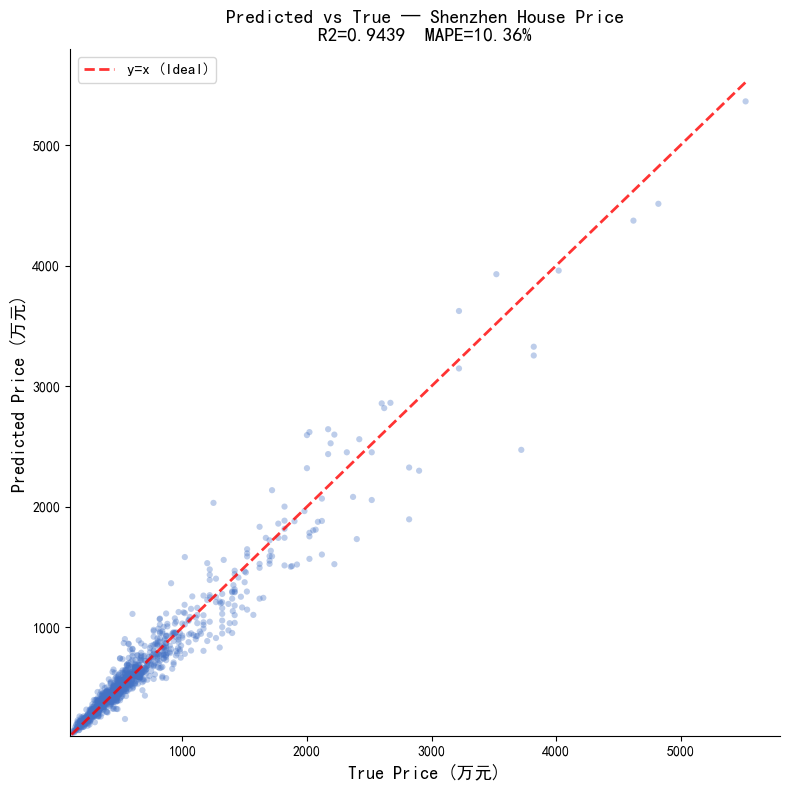

已保存: fig2_predicted_vs_true.png


In [4]:
# ============================================================
# 补充图2: 预测值 vs 真实值散点图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 使用已存在于命名空间的变量: y_test_raw, test_pred
fig, ax = plt.subplots(figsize=(8, 8))

# 绘制散点 (使用透明度处理重叠点)
ax.scatter(y_test_raw, test_pred, alpha=0.35, s=20, c='#4472C4', edgecolors='none')

# 绘制 y=x 理想对角线
max_val = max(y_test_raw.max(), test_pred.max())
min_val = min(y_test_raw.min(), test_pred.min())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (Ideal)', alpha=0.8)

ax.set_xlabel('True Price (万元)', fontsize=13)
ax.set_ylabel('Predicted Price (万元)', fontsize=13)
ax.set_title(f'Predicted vs True — Shenzhen House Price\nR2={r2_score(y_test_raw, test_pred):.4f}  MAPE={np.mean(np.abs(y_test_raw-test_pred)/y_test_raw)*100:.2f}%',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(min_val * 0.9, max_val * 1.05)
ax.set_ylim(min_val * 0.9, max_val * 1.05)

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig2_predicted_vs_true.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存: fig2_predicted_vs_true.png')


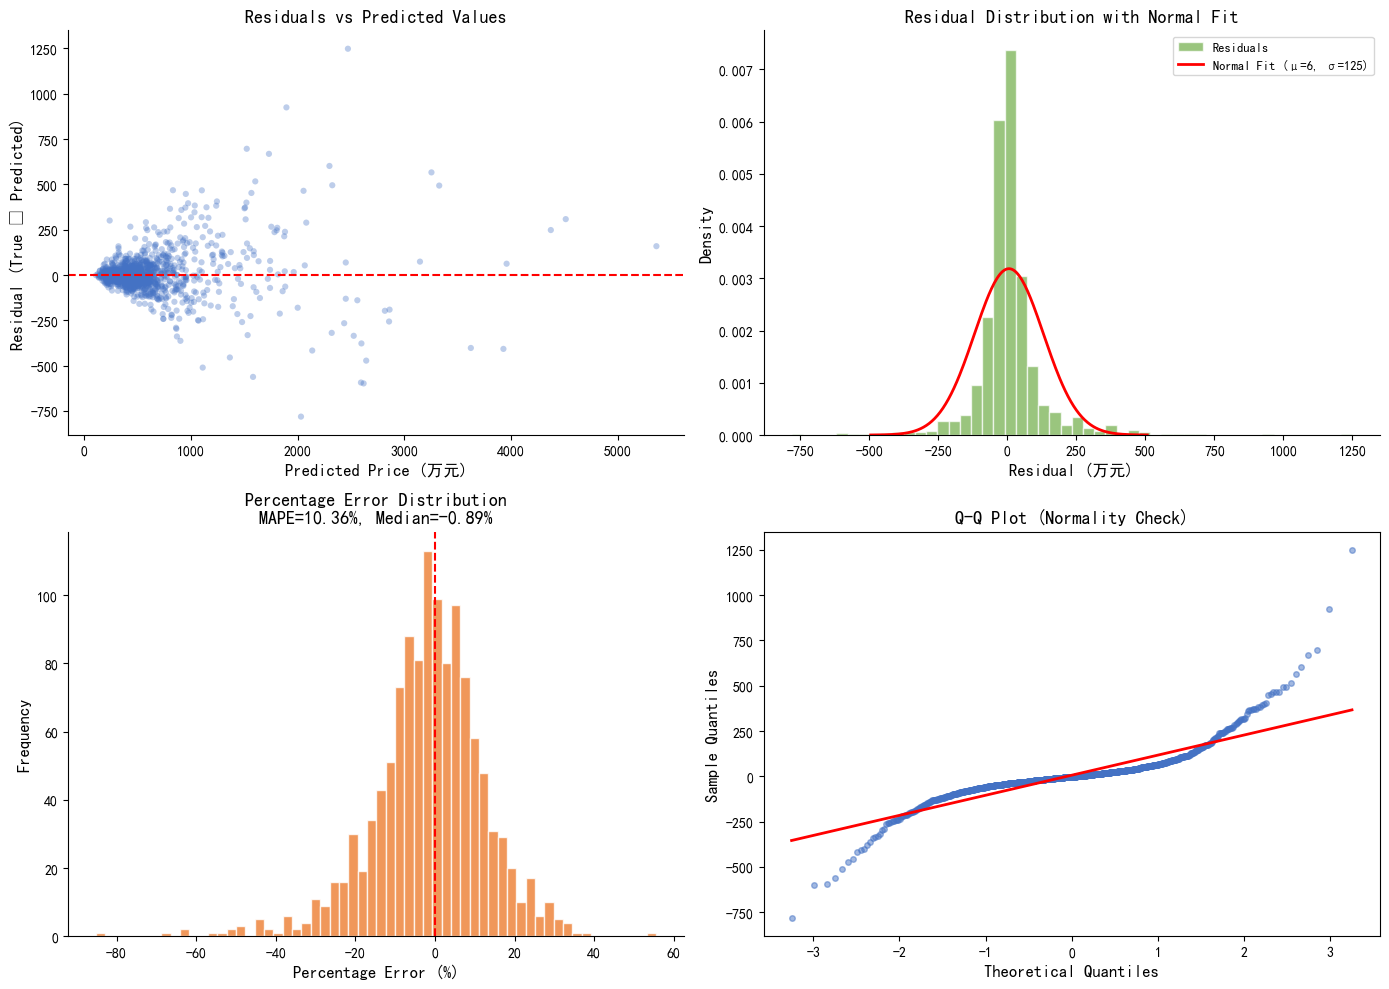

已保存: fig3_residual_analysis.png


In [5]:
# ============================================================
# 补充图3: 残差分布图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

residuals = y_test_raw - test_pred
pct_errors = residuals / y_test_raw * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 子图1: 残差 vs 预测值
ax1 = axes[0, 0]
ax1.scatter(test_pred, residuals, alpha=0.35, s=20, c='#4472C4', edgecolors='none')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Predicted Price (万元)', fontsize=12)
ax1.set_ylabel('Residual (True − Predicted)', fontsize=12)
ax1.set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2: 残差直方图 + 正态拟合
ax2 = axes[0, 1]
ax2.hist(residuals, bins=50, density=True, color='#70AD47', edgecolor='white', alpha=0.7, label='Residuals')
mu, std = residuals.mean(), residuals.std()
x_range = np.linspace(mu - 4*std, mu + 4*std, 200)
ax2.plot(x_range, stats.norm.pdf(x_range, mu, std), 'r-', linewidth=2, label=f'Normal Fit (μ={mu:.0f}, σ={std:.0f})')
ax2.set_xlabel('Residual (万元)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Residual Distribution with Normal Fit', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3: 百分比误差分布
ax3 = axes[1, 0]
ax3.hist(pct_errors, bins=60, color='#ED7D31', edgecolor='white', alpha=0.8)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Percentage Error (%)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(f'Percentage Error Distribution\nMAPE={np.abs(pct_errors).mean():.2f}%, Median={np.median(pct_errors):.2f}%',
             fontsize=13, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 子图4: Q-Q Plot (检验正态性)
ax4 = axes[1, 1]
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.get_lines()[0].set_markerfacecolor('#4472C4')
ax4.get_lines()[0].set_markeredgecolor('#4472C4')
ax4.get_lines()[0].set_markersize(4)
ax4.get_lines()[0].set_alpha(0.5)
ax4.get_lines()[1].set_color('red')
ax4.get_lines()[1].set_linewidth(2)
ax4.set_xlabel('Theoretical Quantiles', fontsize=12)
ax4.set_ylabel('Sample Quantiles', fontsize=12)
ax4.set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig3_residual_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存: fig3_residual_analysis.png')


In [6]:
"""
深圳房价 — 找出均价最高的 10 个片区 (area) 和 10 个小区 (position)
"""
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('house_shenzhen_s.csv', encoding='gbk')

# Top 10 均价最高的 area（至少5个样本）
area_avg = df.groupby('area')['totalprice'].agg(['mean', 'count']).round(0)
area_avg = area_avg[area_avg['count'] >= 1]
area_avg = area_avg.sort_values('mean', ascending=False).head(10)

print('=' * 50)
print('  深圳房屋均价最高的 10 个片区 (area)')
print('=' * 50)
print(f'  {"排名":<5} {"片区":<12} {"均价(万)":<10} {"样本数":<6}')
print(f'  {"-"*33}')
for rank, (area, row) in enumerate(area_avg.iterrows(), 1):
    print(f'  {rank:<5} {area:<12} {int(row["mean"]):<10} {int(row["count"]):<6}')

# Top 10 均价最高的 position（至少5个样本）
pos_avg = df.groupby('position')['totalprice'].agg(['mean', 'count']).round(0)
pos_avg = pos_avg[pos_avg['count'] >= 1]
pos_avg = pos_avg.sort_values('mean', ascending=False).head(10)

print()
print('=' * 50)
print('  深圳房屋均价最高的 10 个小区 (position)')
print('=' * 50)
print(f'  {"排名":<5} {"小区":<20} {"均价(万)":<10} {"样本数":<6}')
print(f'  {"-"*41}')
for rank, (pos, row) in enumerate(pos_avg.iterrows(), 1):
    print(f'  {rank:<5} {pos:<20} {int(row["mean"]):<10} {int(row["count"]):<6}')

  深圳房屋均价最高的 10 个片区 (area)
  排名    片区           均价(万)      样本数   
  ---------------------------------
  1     红树湾          2165       58    
  2     深圳湾          2152       20    
  3     香蜜湖          1791       53    
  4     华侨城          1350       146   
  5     百花           1242       33    
  6     科技园          1092       71    
  7     蛇口           1038       221   
  8     竹子林          988        66    
  9     宝安中心         961        130   
  10    莲花           939        107   

  深圳房屋均价最高的 10 个小区 (position)
  排名    小区                   均价(万)      样本数   
  -----------------------------------------
  1     深圳湾1号                7020       1     
  2     波托菲诺纯水岸十五期           4196       5     
  3     珑御府                  4020       1     
  4     鲸山觐海                 3913       3     
  5     汀兰鹭榭花园               3820       1     
  6     波托菲诺纯水岸九期            3770       1     
  7     波托菲诺纯水岸四期            3600       1     
  8     华侨城LOFT公馆            3520       1     
  9     东海花

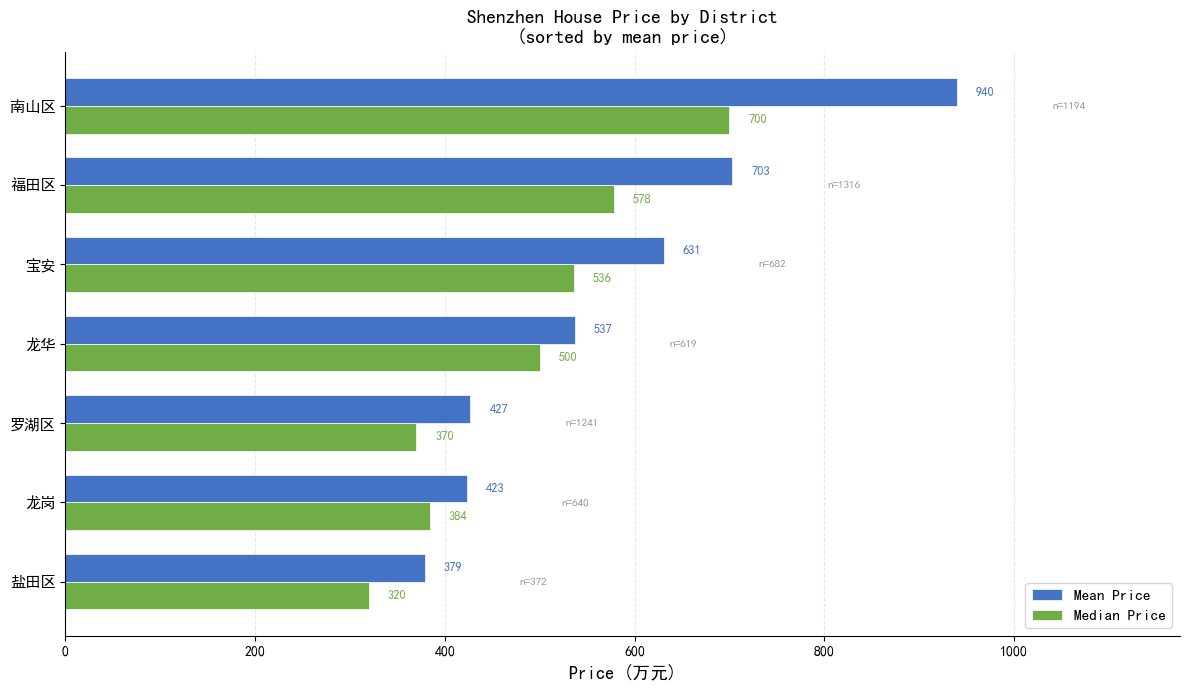

已保存: fig4_district_avg_price.png


In [7]:
# ============================================================
# 补充图4: 各行政区均价对比柱状图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 读取原始数据
df_viz = pd.read_csv('house_shenzhen_s.csv', encoding='gbk')

# 按 city 分组计算均价、中位数、样本数
city_stats = df_viz.groupby('city').agg(
    avg_price=('totalprice', 'mean'),
    median_price=('totalprice', 'median'),
    count=('totalprice', 'count')
).round(0)
city_stats = city_stats[city_stats['count'] >= 5]  # 过滤样本过少的区
city_stats = city_stats.sort_values('avg_price', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = range(len(city_stats))
bar_height = 0.35

# 均价柱
bars1 = ax.barh([y + bar_height/2 for y in y_pos], city_stats['avg_price'],
                bar_height, color='#4472C4', edgecolor='white', linewidth=0.5, label='Mean Price', zorder=2)
# 中位数柱
bars2 = ax.barh([y - bar_height/2 for y in y_pos], city_stats['median_price'],
                bar_height, color='#70AD47', edgecolor='white', linewidth=0.5, label='Median Price', zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(city_stats.index, fontsize=11)
ax.set_xlabel('Price (万元)', fontsize=13)
ax.set_title(f'Shenzhen House Price by District\n(sorted by mean price)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')

# 在每个柱子右侧标注数值
for i, (idx, row) in enumerate(city_stats.iterrows()):
    ax.text(row['avg_price'] + 20, i + bar_height/2, f"{row['avg_price']:.0f}",
            va='center', fontsize=9, color='#4472C4', fontweight='bold')
    ax.text(row['median_price'] + 20, i - bar_height/2, f"{row['median_price']:.0f}",
            va='center', fontsize=9, color='#70AD47')
    # 样本数标注在最右侧
    ax.text(max(row['avg_price'], row['median_price']) + 100, i,
            f"n={int(row['count'])}", va='center', fontsize=8, color='#999')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, city_stats['avg_price'].max() * 1.25)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig4_district_avg_price.png', dpi=200, bbox_inches='tight')
plt.show()
print('已保存: fig4_district_avg_price.png')


In [ ]:
# ============================================================
# Part 8: SHAP 可解释性分析 (兼容 SHAP 0.52.0 + XGBoost 3.2.0)
# ============================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# TreeExplainer — XGBoost 原生支持
explainer = shap.TreeExplainer(model_full)
ev = explainer.expected_value
if isinstance(ev, np.ndarray):
    ev = float(ev[0]) if len(ev) > 0 else float(ev)
print(f"Expected value (base value): {ev:.4f} (sqrt scale, ≈ {ev**2:.0f} 万元)")

# 使用测试集计算 SHAP 值
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, shap.Explanation):
    shap_values = shap_values.values
print(f"SHAP values shape: {shap_values.shape}")
print(f"  (n_samples={shap_values.shape[0]}, n_features={shap_values.shape[1]})")

# ============================================================
# 8.1: 数值输出 — 每个特征 (合并后) 的 mean(|SHAP|)
# ============================================================
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance_dict = dict(zip(feature_cols, shap_importance))

# 合并同类特征 (与 Part 5 合并逻辑一致)
groups = {
    'area':        [c for c in feature_cols if c.startswith('area_')],
    'city':        [c for c in feature_cols if c.startswith('city_')],
    'orientation': [c for c in feature_cols if c.startswith('ori_')],
    'buildtype':   [c for c in feature_cols if c.startswith('buildtype_')],
    'rooms':       ['room_num', 'hall_num'],
}
grouped = set()
for cols in groups.values():
    grouped.update(cols)

merged_shap = {}
for name, cols in groups.items():
    cols_in = [c for c in cols if c in feature_cols]
    if cols_in:
        merged_shap[name] = sum(shap_importance_dict[c] for c in cols_in)
for col in feature_cols:
    if col not in grouped:
        merged_shap[col] = shap_importance_dict[col]

merged_shap_sorted = sorted(merged_shap.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*55}")
print(f"  SHAP 特征重要性 (mean |SHAP|, sqrt scale)")
print(f"{'='*55}")
print(f"  {'排名':<5} {'特征':<16} {'mean|SHAP|':<12}")
print(f"  {'-'*33}")
for rank, (feat, val) in enumerate(merged_shap_sorted, 1):
    print(f"  {rank:<5} {feat:<16} {val:<12.4f}")

# ============================================================
# 8.2: SHAP Summary Plot (蜜蜂图) — 展示 Top 15 原始特征
# ============================================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig5_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('\n已保存: fig5_shap_summary.png')

# ============================================================
# 8.3: SHAP Bar Plot — mean(|SHAP|) 柱状图
# ============================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', max_display=15, show=False)
plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig6_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('已保存: fig6_shap_bar.png')

# ============================================================
# 8.4: Waterfall 瀑布图 — 单个样本预测解释
# ============================================================
from matplotlib.font_manager import FontProperties
cn_font = FontProperties(family='Microsoft YaHei')

exp = explainer(X_test.iloc[:1])
plt.figure(figsize=(10, 8))
shap.plots.waterfall(exp[0], max_display=15, show=False)

# 强制所有文字使用中文字体，修复 SHAP waterfall 图中文方框乱码
ax = plt.gca()
for child in ax.get_children():
    if isinstance(child, matplotlib.text.Text):
        child.set_fontproperties(cn_font)

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig7_shap_waterfall_single.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('已保存: fig7_shap_waterfall_single.png')

# ============================================================
# 8.5: Dependence Plot — 最重要连续特征 'size' 的 SHAP 依赖图
# ============================================================
plt.figure(figsize=(10, 6))
shap.dependence_plot('size', shap_values, X_test, feature_names=feature_cols,
                     show=False)
plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig8_shap_dependence_size.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('已保存: fig8_shap_dependence_size.png')

# ============================================================
# 8.6: SHAP 依赖性图 — Top 3 非合并特征
# ============================================================
top_features_shap = [f for f, _ in merged_shap_sorted 
                     if f not in ['area', 'city', 'buildtype', 'orientation', 'rooms']][:3]
print(f'\n  Top individual features by SHAP: {top_features_shap}')

fig, axes = plt.subplots(1, len(top_features_shap), figsize=(15, 5))
if len(top_features_shap) == 1:
    axes = [axes]
for i, feat in enumerate(top_features_shap):
    plt.sca(axes[i])
    shap.dependence_plot(feat, shap_values, X_test, feature_names=feature_cols,
                         show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig9_shap_dependence_top3.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('已保存: fig9_shap_dependence_top3.png')

# ============================================================
# 8.7: XGBoost vs SHAP 特征重要性对比
# ============================================================
xgb_merged = {}
for name, cols in groups.items():
    cols_in = [c for c in cols if c in feature_cols]
    if cols_in:
        xgb_merged[name] = sum(raw_importance[c] for c in cols_in)
for col in feature_cols:
    if col not in grouped:
        xgb_merged[col] = raw_importance[col]

# 归一化 SHAP 便于对比
total_shap = sum(v for _, v in merged_shap.items())
shap_norm = {k: v/total_shap for k, v in merged_shap.items()}

compare_sorted = sorted(xgb_merged.items(), key=lambda x: x[1], reverse=True)
feat_list = [x[0] for x in compare_sorted]
xgb_vals = [xgb_merged[f] for f in feat_list]
shap_vals = [shap_norm.get(f, 0) for f in feat_list]

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(feat_list))
width = 0.35
ax.bar(x_pos - width/2, xgb_vals, width, label='XGBoost Gain', color='#4472C4', edgecolor='white')
ax.bar(x_pos + width/2, shap_vals, width, label='SHAP (normalized)', color='#70AD47', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_list, fontsize=11)
ax.set_ylabel('Importance', fontsize=12)
ax.set_title('Feature Importance: XGBoost Gain vs SHAP', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(r'D:\Desktop_new\fig10_importance_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
plt.clf()
print('已保存: fig10_importance_comparison.png')

# ============================================================
# 8.8: 保存 SHAP 结果
# ============================================================
shap_df = pd.DataFrame({
    'feature': [x[0] for x in merged_shap_sorted],
    'mean_abs_shap': [x[1] for x in merged_shap_sorted],
    'xgb_gain': [xgb_merged.get(x[0], 0) for x in merged_shap_sorted],
    'shap_normalized': [shap_norm.get(x[0], 0) for x in merged_shap_sorted],
})
shap_df.to_csv(r'D:\Desktop_new\shap_feature_importance.csv', index=False, encoding='utf-8-sig')
print('已保存: shap_feature_importance.csv')
print("\nSHAP 分析完成！")